# Customer Review NLP
Sentiment classification, emotion detection, and LLM-based review summarisation using NLTK and Hugging Face Transformers.


## 1. Business Problem
Use customer review text to understand sentiment, product strengths, complaints, and seller performance.


## 2. Business Objectives
- Classify reviews as positive, negative, or neutral
- Detect simple customer emotions
- Summarise review themes with LLM prompts


## 3. NLP Workflow
Text Preparation ? Sentiment Models ? Evaluation ? Emotion Detection ? LLM Summarisation


In [1]:
import warnings
warnings.filterwarnings("ignore")
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

try:
    from transformers import pipeline
except ImportError:
    pipeline = None

for resource in ["stopwords", "wordnet", "vader_lexicon"]:
    try:
        nltk.download(resource, quiet=True)
    except Exception:
        pass


## 4. Load Dataset


In [2]:
master_df = pd.read_parquet(Path("../data/processed/master_df.parquet"))
master_df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_name,...,payment_sequential,payment_type,payment_installments,payment_value,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaT,NaT,2026-01-04 08:33:20,d45cdff2-5195-41e2-a0e5-6fe597e378dd,James Ramos,...,1,paypal,1,2084.010010,None,NaN,None,None,NaT,NaT
1,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaT,NaT,2026-01-04 08:33:20,d45cdff2-5195-41e2-a0e5-6fe597e378dd,James Ramos,...,1,paypal,1,2084.010010,None,NaN,None,None,NaT,NaT
2,720fd9e9-cdeb-4dec-a187-f71586eb085a,1e2e2881-a0eb-4cb0-829f-a566e810d05f,canceled,2025-12-27 07:07:20,2025-12-27 08:33:20,NaT,NaT,2026-01-04 08:33:20,d45cdff2-5195-41e2-a0e5-6fe597e378dd,James Ramos,...,1,paypal,1,2084.010010,None,NaN,None,None,NaT,NaT
3,c0142972-63fa-4af2-8070-f583ab769847,380b7418-308c-4bf7-b2bd-3ee446cb9ea6,delivered,2019-06-07 19:30:44,2019-06-08 05:08:44,2019-06-09 05:08:44,2019-06-14 05:08:44,2019-06-16 05:08:44,35cee471-325e-4ad2-8e4e-7b169dc6df81,Brian Jackson,...,1,credit_card,6,1406.069946,0ba49642-47bb-4817-9cc2-bb9ded7de7c5,5.0,Perfect,The quality is amazing. Delivery was quick.,2019-06-19 05:08:44,2019-06-19 07:08:44
4,c0142972-63fa-4af2-8070-f583ab769847,380b7418-308c-4bf7-b2bd-3ee446cb9ea6,delivered,2019-06-07 19:30:44,2019-06-08 05:08:44,2019-06-09 05:08:44,2019-06-14 05:08:44,2019-06-16 05:08:44,35cee471-325e-4ad2-8e4e-7b169dc6df81,Brian Jackson,...,1,credit_card,6,1406.069946,0ba49642-47bb-4817-9cc2-bb9ded7de7c5,5.0,Perfect,The quality is amazing. Delivery was quick.,2019-06-19 05:08:44,2019-06-19 07:08:44


## 5. Review Dataset


In [3]:
review_cols = ["review_comment_message", "review_score", "product_id", "seller_id"]

# Keep all rows for business-frequency reporting. The joined master table can repeat
# a review across order items, so repeated rows are not independent NLP examples.
reviews_all = master_df[review_cols].dropna(
    subset=["review_comment_message", "review_score"]
).copy()
reviews_all["review_comment_message"] = reviews_all["review_comment_message"].str.strip()
reviews_all = reviews_all[reviews_all["review_comment_message"].ne("")]

# Detect conflicts at the sentiment level, not the exact-star level:
# scores 4 and 5 are both Positive, while scores 1 and 2 are both Negative.
reviews_all["_sentiment_group"] = np.select(
    [
        reviews_all["review_score"].isin([1, 2]),
        reviews_all["review_score"].eq(3),
        reviews_all["review_score"].isin([4, 5]),
    ],
    ["Negative", "Neutral", "Positive"],
    default="Unknown",
)
text_label_counts = reviews_all.groupby("review_comment_message")["_sentiment_group"].nunique()
conflicting_texts = text_label_counts[text_label_counts > 1].index
reviews = (
    reviews_all[~reviews_all["review_comment_message"].isin(conflicting_texts)]
    .drop_duplicates(subset=["review_comment_message", "_sentiment_group"])
    .copy()
)

print(f"Joined review rows: {len(reviews_all):,}")
print(f"Unique review texts: {len(reviews):,}")
print(f"Texts with conflicting scores excluded: {len(conflicting_texts):,}")
display(reviews.head())


Joined review rows: 2,362,704
Unique review texts: 649
Texts with conflicting scores excluded: 0


,review_comment_message,review_score,product_id,seller_id,_sentiment_group
3,The quality is amazing. Delivery was quick.,5.0,5816f107-b725-4c41-b794-298bf9669a41,91fe2cc8-51a5-4c79-9c12-cea5ae013f55,Positive
6,The service is excellent. Super fast shipping.,5.0,dba76d6c-f93c-466a-b035-673fd66c9191,87dff9d3-3e93-476c-a5a8-af4f870440b1,Positive
12,The item is fantastic. Arrived early!,5.0,7361613a-9d89-468a-949f-dfbf9ee36b5f,7176f283-cb32-4e70-94fc-726d1d1e8297,Positive
26,The product is good. Delivery was quick.,5.0,48be949b-1636-4e89-917e-064932a2cfdf,43f8bbc2-1072-455e-b71b-c3e85808a8bb,Positive
28,The item is fantastic. Super fast shipping.,5.0,1f2e01bd-25d2-4720-b83b-7ab216c59191,13e29408-79f2-4b94-b640-e3593bb96ee4,Positive


## 6. Data Quality Check


In [4]:
quality_summary = pd.DataFrame({
    "Metric": [
        "Joined rows",
        "Unique review texts",
        "Repeated-row rate",
        "Conflicting text labels",
    ],
    "Value": [
        len(reviews_all),
        len(reviews),
        1 - len(reviews) / len(reviews_all),
        len(conflicting_texts),
    ],
})
display(quality_summary.style.format({"Value": lambda x: f"{x:.2%}" if 0 <= x <= 1 else f"{x:,.0f}"}))


,Metric,Value
0,Joined rows,"2,362,704"
1,Unique review texts,649
2,Repeated-row rate,99.97%
3,Conflicting text labels,0.00%


## 7. Missing Values Handling


In [5]:
reviews["review_comment_message"] = reviews["review_comment_message"].fillna("")
reviews["seller_id"] = reviews["seller_id"].fillna("unknown")


## 8. Duplicate Analysis


In [6]:
print("Duplicate review texts:", reviews["review_comment_message"].duplicated().sum())


Duplicate review texts: 0


## 9. Sentiment Definition


Review scores 4?5 are Positive, score 3 is Neutral, and scores 1?2 are Negative. These labels train supervised sentiment models.


## 10. Sentiment Labels


In [7]:
def score_to_sentiment(score):
    if score in (1, 2):
        return "Negative"
    if score == 3:
        return "Neutral"
    if score in (4, 5):
        return "Positive"
    return np.nan

reviews_all["Sentiment"] = reviews_all["review_score"].apply(score_to_sentiment)
reviews["Sentiment"] = reviews["review_score"].apply(score_to_sentiment)

label_audit = pd.concat(
    [
        reviews_all["Sentiment"].value_counts().rename("Rows including repeats"),
        reviews["Sentiment"].value_counts().rename("Unique texts"),
    ],
    axis=1,
).fillna(0).astype(int).reindex(["Negative", "Neutral", "Positive"])
label_audit["Unique-text share"] = (
    label_audit["Unique texts"] / label_audit["Rows including repeats"]
)
display(label_audit.style.format({"Unique-text share": "{:.2%}"}))

if label_audit.loc["Neutral", "Unique texts"] < 10:
    print("Neutral is retained for reporting but excluded from supervised modeling:")
    print("repeated copies of one sentence do not provide enough independent evidence.")


,Rows including repeats,Unique texts,Unique-text share
Sentiment,,,
Negative,436111,216,0.05%
Neutral,204057,1,0.00%
Positive,1722536,432,0.03%


Neutral is retained for reporting but excluded from supervised modeling:
repeated copies of one sentence do not provide enough independent evidence.


## 11. Text Cleaning with NLTK


In [8]:
try:
    stop_words = set(stopwords.words("english"))
except LookupError:
    stop_words = set()
lemmatizer = WordNetLemmatizer()

def clean_review(text):
    text = re.sub(r"[^a-zA-Z\s]", " ", str(text).lower())
    tokens = [word for word in text.split() if word not in stop_words and len(word) > 2]
    return " ".join(tokens)

reviews["clean_text"] = reviews["review_comment_message"].apply(clean_review)
reviews = reviews[reviews["clean_text"].str.len() > 0].copy()
display(reviews[["review_comment_message", "clean_text", "Sentiment"]].head())


,review_comment_message,clean_text,Sentiment
3,The quality is amazing. Delivery was quick.,quality amazing delivery quick,Positive
6,The service is excellent. Super fast shipping.,service excellent super fast shipping,Positive
12,The item is fantastic. Arrived early!,item fantastic arrived early,Positive
26,The product is good. Delivery was quick.,product good delivery quick,Positive
28,The item is fantastic. Super fast shipping.,item fantastic super fast shipping,Positive


## 12. Sentiment Distribution


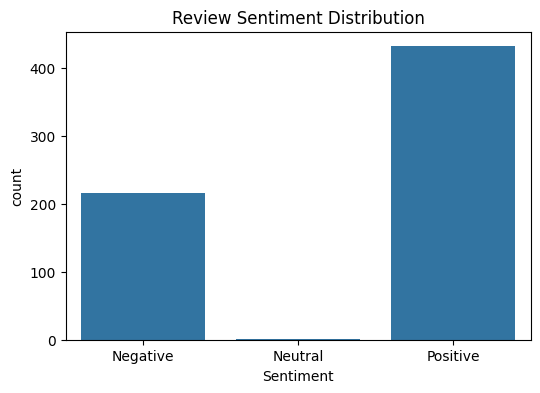

In [9]:
plt.figure(figsize=(6, 4))
sns.countplot(data=reviews, x="Sentiment", order=["Negative", "Neutral", "Positive"])
plt.title("Review Sentiment Distribution")
plt.show()


## 13. Train/Test Split


In [10]:
# Model only sentiment classes with enough independent text examples.
SUPPORTED_MODEL_CLASSES = ["Negative", "Positive"]
MIN_UNIQUE_TEXTS_PER_CLASS = 20

model_reviews = reviews[
    reviews["Sentiment"].isin(SUPPORTED_MODEL_CLASSES)
].copy()
class_counts = model_reviews["Sentiment"].value_counts()
insufficient = {
    name: int(class_counts.get(name, 0))
    for name in SUPPORTED_MODEL_CLASSES
    if class_counts.get(name, 0) < MIN_UNIQUE_TEXTS_PER_CLASS
}
if insufficient:
    raise ValueError(
        f"Insufficient unique review texts for modeling: {insufficient}. "
        "Check the sentiment mapping and duplicate-conflict logic."
    )

X = model_reviews["clean_text"]
y = model_reviews["Sentiment"]
if y.nunique() != len(SUPPORTED_MODEL_CLASSES):
    raise ValueError(f"Expected {SUPPORTED_MODEL_CLASSES}, found {sorted(y.unique())}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Distinct texts used for modeling:")
print(y.value_counts())
print("Reporting-only classes:", sorted(set(reviews["Sentiment"]) - set(SUPPORTED_MODEL_CLASSES)))
print("Training class counts:")
print(y_train.value_counts())
print("Testing class counts:")
print(y_test.value_counts())


Distinct texts used for modeling:
Sentiment
Positive    432
Negative    216
Name: count, dtype: int64
Reporting-only classes: ['Neutral']
Training class counts:
Sentiment
Positive    345
Negative    173
Name: count, dtype: int64
Testing class counts:
Sentiment
Positive    87
Negative    43
Name: count, dtype: int64


## 14. TF-IDF Preprocessing


In [11]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)


## 15. Logistic Regression


In [12]:
log_reg_pipeline = Pipeline([
    ("tfidf", tfidf),
    ("classifier", LogisticRegression(max_iter=1000, random_state=42))
])
log_reg_pipeline.fit(X_train, y_train)
log_reg_pred = log_reg_pipeline.predict(X_test)
print("=" * 60)
print("Logistic Regression Results")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, log_reg_pred):.4f}")
print(classification_report(y_test, log_reg_pred))


Logistic Regression Results
Accuracy: 1.0000
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        43
    Positive       1.00      1.00      1.00        87

    accuracy                           1.00       130
   macro avg       1.00      1.00      1.00       130
weighted avg       1.00      1.00      1.00       130



## 16. Naive Bayes


In [13]:
nb_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)),
    ("classifier", MultinomialNB())
])
nb_pipeline.fit(X_train, y_train)
nb_pred = nb_pipeline.predict(X_test)
print("=" * 60)
print("Naive Bayes Results")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, nb_pred):.4f}")
print(classification_report(y_test, nb_pred))


Naive Bayes Results
Accuracy: 1.0000
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        43
    Positive       1.00      1.00      1.00        87

    accuracy                           1.00       130
   macro avg       1.00      1.00      1.00       130
weighted avg       1.00      1.00      1.00       130



## 17. Support Vector Machine


In [14]:
svm_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2)),
    ("classifier", LinearSVC())
])
svm_pipeline.fit(X_train, y_train)
svm_pred = svm_pipeline.predict(X_test)
print("=" * 60)
print("SVM Results")
print("=" * 60)
print(f"Accuracy: {accuracy_score(y_test, svm_pred):.4f}")
print(classification_report(y_test, svm_pred))


SVM Results
Accuracy: 1.0000
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        43
    Positive       1.00      1.00      1.00        87

    accuracy                           1.00       130
   macro avg       1.00      1.00      1.00       130
weighted avg       1.00      1.00      1.00       130



## 18. BERT Sentiment Analysis


In [15]:
if pipeline is not None:
    bert_sentiment = pipeline("sentiment-analysis")
    bert_sample = X_test.head(20).tolist()
    bert_results = bert_sentiment(bert_sample, truncation=True)
    display(pd.DataFrame({"Review": bert_sample, "BERT_Label": [x["label"] for x in bert_results], "BERT_Score": [x["score"] for x in bert_results]}))
else:
    print("Hugging Face Transformers is not installed. Install transformers to run BERT.")


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


Device set to use cpu


,Review,BERT_Label,BERT_Score
0,quality good arrived early good price,POSITIVE,0.999774
1,product great super fast shipping steal,POSITIVE,0.995511
2,material amazing delivery quick great value,POSITIVE,0.999884
3,design excellent delivery quick steal,POSITIVE,0.999448
4,quality bad expensive,NEGATIVE,0.999752
5,item excellent arrived early good price,POSITIVE,0.999681
6,material poor overpriced,NEGATIVE,0.999783
7,item disappointing arrived late,NEGATIVE,0.997934
8,product good arrived early,POSITIVE,0.998700
9,design fantastic delivery quick,POSITIVE,0.999869


## 19. Cross Validation


In [16]:
models = {
    "Logistic Regression": log_reg_pipeline,
    "Naive Bayes": nb_pipeline,
    "SVM": svm_pipeline
}
n_splits = min(5, y_train.value_counts().min())
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
cv_results = []
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy")
    cv_results.append({"Model": name, "CV Accuracy Mean": scores.mean(), "CV Accuracy Std": scores.std()})
cv_results = pd.DataFrame(cv_results).sort_values("CV Accuracy Mean", ascending=False)
best_model_name = cv_results.iloc[0]["Model"]
display(cv_results)


,Model,CV Accuracy Mean,CV Accuracy Std
0,Logistic Regression,1.0,0.0
1,Naive Bayes,1.0,0.0
2,SVM,1.0,0.0


## 20. Best Model Evaluation


In [17]:
best_pipeline = models[best_model_name]
best_pipeline.fit(X_train, y_train)
best_pred = best_pipeline.predict(X_test)
print(f"Selected model: {best_model_name}")
print(f"Test Accuracy: {accuracy_score(y_test, best_pred):.4f}")
print(classification_report(y_test, best_pred))


Selected model: Logistic Regression
Test Accuracy: 1.0000
              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        43
    Positive       1.00      1.00      1.00        87

    accuracy                           1.00       130
   macro avg       1.00      1.00      1.00       130
weighted avg       1.00      1.00      1.00       130



## 21. Model Comparison

The source reviews are synthetic and use sentiment-specific template words. Perfect scores measure separation of these templates, not expected performance on real reviews.


In [18]:
from sklearn.metrics import f1_score, balanced_accuracy_score

predictions_by_model = {
    "Logistic Regression": log_reg_pred,
    "Naive Bayes": nb_pred,
    "SVM": svm_pred,
}
cv_lookup = cv_results.set_index("Model")
comparison = pd.DataFrame([
    {
        "Model": name,
        "Template Test Accuracy": accuracy_score(y_test, pred),
        "Template Macro F1": f1_score(y_test, pred, average="macro"),
        "CV Mean": cv_lookup.loc[name, "CV Accuracy Mean"],
        "CV Std": cv_lookup.loc[name, "CV Accuracy Std"],
        "Selected": name == best_model_name,
    }
    for name, pred in predictions_by_model.items()
]).sort_values(["CV Mean", "Template Macro F1"], ascending=False).reset_index(drop=True)

display(comparison.style.format({
    "Template Test Accuracy": "{:.4f}", "Template Macro F1": "{:.4f}",
    "CV Mean": "{:.4f}", "CV Std": "{:.4f}",
}))
print("These scores measure recognition of synthetic templates and are not deployment estimates.")


,Model,Template Test Accuracy,Template Macro F1,CV Mean,CV Std,Selected
0,Logistic Regression,1.0000,1.0000,1.0000,0.0000,True
1,Naive Bayes,1.0000,1.0000,1.0000,0.0000,False
2,SVM,1.0000,1.0000,1.0000,0.0000,False


These scores measure recognition of synthetic templates and are not deployment estimates.


## 21A. Realistic Language Stress Test

This small, manually labeled challenge set is not a replacement for external validation. It checks whether models trained on simple templates handle negation, mixed opinions, comparisons, and indirect complaints. It is reported separately and is not used for training.


In [19]:
challenge_reviews = pd.DataFrame([
    ("The product looks great, but it stopped working after two days.", "Negative"),
    ("Delivery was fast; unfortunately the item inside was damaged.", "Negative"),
    ("I wanted to love it, but the quality does not justify the price.", "Negative"),
    ("Not as reliable as the description suggested.", "Negative"),
    ("The replacement arrived, although the original order was a disaster.", "Negative"),
    ("It is not terrible, but I would not recommend buying it.", "Negative"),
    ("The packaging was beautiful while the product itself was unusable.", "Negative"),
    ("Support replied quickly but never solved the problem.", "Negative"),
    ("I expected very little and was pleasantly surprised by the quality.", "Positive"),
    ("The box was damaged, but the product works perfectly.", "Positive"),
    ("It took a while to arrive, yet it was worth the wait.", "Positive"),
    ("Not the cheapest option, though the build quality is excellent.", "Positive"),
    ("I was worried by the reviews, but mine has worked without an issue.", "Positive"),
    ("The color differs slightly from the photo; otherwise I am very happy.", "Positive"),
    ("Customer service fixed the initial mistake immediately.", "Positive"),
    ("After a week of use, it has exceeded my expectations.", "Positive"),
], columns=["Review", "Sentiment"])

challenge_reviews["clean_text"] = challenge_reviews["Review"].apply(clean_review)
challenge_rows = []
for name, model in models.items():
    pred = model.predict(challenge_reviews["clean_text"])
    challenge_rows.append({
        "Model": name,
        "Challenge Accuracy": accuracy_score(challenge_reviews["Sentiment"], pred),
        "Challenge Balanced Accuracy": balanced_accuracy_score(challenge_reviews["Sentiment"], pred),
        "Challenge Macro F1": f1_score(challenge_reviews["Sentiment"], pred, average="macro"),
    })

challenge_comparison = pd.DataFrame(challenge_rows).sort_values(
    "Challenge Macro F1", ascending=False
).reset_index(drop=True)
display(challenge_comparison.style.format({
    "Challenge Accuracy": "{:.4f}",
    "Challenge Balanced Accuracy": "{:.4f}",
    "Challenge Macro F1": "{:.4f}",
}))

best_challenge_model = challenge_comparison.iloc[0]["Model"]
print(f"Best stress-test model: {best_challenge_model}")
print("Collect a larger independent review set before making a deployment decision.")


,Model,Challenge Accuracy,Challenge Balanced Accuracy,Challenge Macro F1
0,Naive Bayes,0.5000,0.5000,0.4182
1,SVM,0.3750,0.3750,0.3333
2,Logistic Regression,0.3125,0.3125,0.2874


Best stress-test model: Naive Bayes
Collect a larger independent review set before making a deployment decision.


## 22. Confusion Matrix


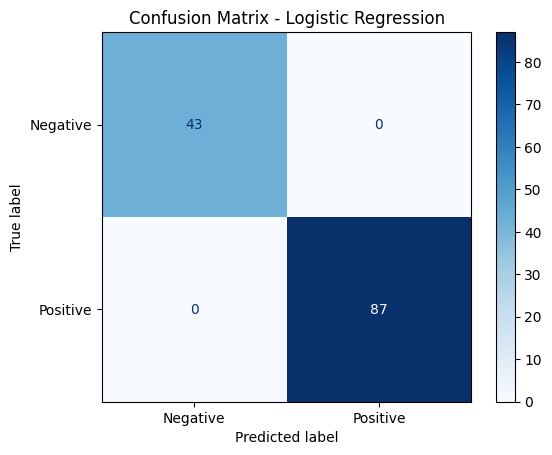

In [20]:
ConfusionMatrixDisplay.from_predictions(y_test, best_pred, cmap="Blues")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()


## 23. Important Words


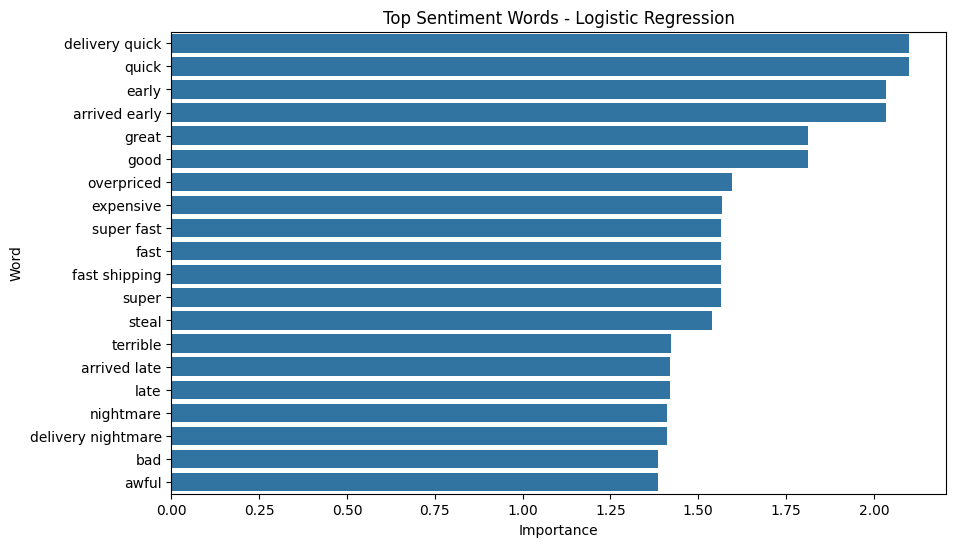

,Word,Importance
23,delivery quick,2.101473
145,quick,2.101473
44,early,2.033368
5,arrived early,2.033368
65,great,1.812091
60,good,1.811510
106,overpriced,1.596895
52,expensive,1.567343
169,super fast,1.565096
57,fast,1.565096


In [21]:
if hasattr(best_pipeline.named_steps["classifier"], "coef_"):
    feature_names = best_pipeline.named_steps["tfidf"].get_feature_names_out()
    importance = np.abs(best_pipeline.named_steps["classifier"].coef_).mean(axis=0)
    top_words = pd.DataFrame({"Word": feature_names, "Importance": importance}).sort_values("Importance", ascending=False).head(20)
    plt.figure(figsize=(10, 6))
    sns.barplot(data=top_words, x="Importance", y="Word")
    plt.title(f"Top Sentiment Words - {best_model_name}")
    plt.show()
    display(top_words)


## 24. Emotion Detection


In [22]:
emotion_keywords = {
    "Joy": ["love", "great", "excellent", "happy", "amazing"],
    "Anger": ["worst", "hate", "angry", "terrible", "awful"],
    "Sadness": ["sad", "disappointed", "broken", "regret"],
    "Trust": ["reliable", "trust", "quality", "recommend"]
}
def detect_emotion(text):
    text = text.lower()
    scores = {emotion: sum(word in text for word in words) for emotion, words in emotion_keywords.items()}
    return max(scores, key=scores.get) if max(scores.values()) > 0 else "Neutral"
reviews["Emotion"] = reviews["clean_text"].apply(detect_emotion)
display(reviews["Emotion"].value_counts().to_frame("Count"))


,Count
Emotion,
Joy,271
Neutral,255
Anger,72
Trust,51


## 25. Top Complaints


In [23]:
negative_reviews = reviews[reviews["Sentiment"] == "Negative"]
print("Top negative review examples")
display(negative_reviews[["review_comment_message", "product_id", "seller_id"]].head(20))


Top negative review examples


,review_comment_message,product_id,seller_id
50,The quality is awful. Shipping took forever.,549f38cb-4c1b-4af3-9136-720b2a5a096a,d3e90e89-11ec-4686-9c8b-9057ffff1cc8
53,The quality is bad. Overpriced.,83fbdf52-21a3-4b64-af45-76ff4437130b,2a119708-10a2-446a-88ba-6720949173cd
82,The service is awful. Overpriced.,775fda99-84ae-4a0d-b9b8-91796add66e8,80d6afd3-3dc3-457f-a630-b6ac544f52fa
86,The material is disappointing. Delivery was a ...,fa6e102c-4eda-4fbb-93eb-d081fb261a65,fa3925d1-da80-4e20-9f2f-dd8e20211f3f
88,The item is poor. Arrived very late.,236a9514-2ee7-4565-9a5c-265ba1322ea6,3a840d5a-70f3-45c9-b22a-34b00289cd23
106,The item is poor. Shipping took forever.,0325b2ba-fe12-4ad6-ad89-28c56b40e679,a935ca8d-c843-4211-849c-b9c48005b105
121,The quality is poor. Shipping took forever.,655e743c-ee08-4465-8581-5e0ba3e9feb1,c66b4a36-3943-4b00-9c04-f12e52ebbb55
128,The item is bad. Too expensive.,16ee6f17-88b6-4c19-bc29-edba4dc497f2,d5d41f35-d15a-4e9b-afb3-1d339eb1f7f9
182,The product is horrible. Delivery was a nightm...,86ce63d8-6e1e-4e01-b9c0-be2a8873c001,5b90a8af-6694-417e-b81e-9c4333a3b2d1
207,The design is disappointing. Shipping took for...,224d3e84-0c5b-4156-a45f-d6691af447df,13e29408-79f2-4b94-b640-e3593bb96ee4


## 26. Product Strengths


In [24]:
positive_reviews = reviews[reviews["Sentiment"] == "Positive"]
print("Top positive review examples")
display(positive_reviews[["review_comment_message", "product_id", "seller_id"]].head(20))


Top positive review examples


,review_comment_message,product_id,seller_id
3,The quality is amazing. Delivery was quick.,5816f107-b725-4c41-b794-298bf9669a41,91fe2cc8-51a5-4c79-9c12-cea5ae013f55
6,The service is excellent. Super fast shipping.,dba76d6c-f93c-466a-b035-673fd66c9191,87dff9d3-3e93-476c-a5a8-af4f870440b1
12,The item is fantastic. Arrived early!,7361613a-9d89-468a-949f-dfbf9ee36b5f,7176f283-cb32-4e70-94fc-726d1d1e8297
26,The product is good. Delivery was quick.,48be949b-1636-4e89-917e-064932a2cfdf,43f8bbc2-1072-455e-b71b-c3e85808a8bb
28,The item is fantastic. Super fast shipping.,1f2e01bd-25d2-4720-b83b-7ab216c59191,13e29408-79f2-4b94-b640-e3593bb96ee4
29,The quality is fantastic. Arrived early!,c6473e15-ddb4-42da-bea4-f1ffe947e5a1,619039bb-f141-4315-b6df-75ea50cc32aa
31,The quality is excellent. Arrived early!,5a3f9631-989c-4854-b6e2-96c2c3f85899,2e908ea9-3a34-48c1-90ae-4777b26b1474
36,The product is fantastic. Super fast shipping.,a4f3c515-b1eb-41c3-97ab-90c6e49c3a2c,9a4649de-c63d-4307-b98d-336b77119690
40,The product is amazing. Delivery was quick.,660f7938-04d3-4fa8-94d0-213911c27f08,b397f479-9909-47d7-9fac-7b9680ac9dd5
41,The design is perfect. Arrived early!,238ac5fa-8747-47f8-adc0-d28aa44c5e4b,36190911-cba6-4044-9745-02d1956604b4


## 27. Seller Summary


In [25]:
seller_summary = reviews.groupby("seller_id").agg(
    Reviews=("Sentiment", "size"),
    Positive_Rate=("Sentiment", lambda x: (x == "Positive").mean()),
    Negative_Rate=("Sentiment", lambda x: (x == "Negative").mean())
).sort_values("Negative_Rate", ascending=False)
display(seller_summary.head(20))


,Reviews,Positive_Rate,Negative_Rate
seller_id,,,
feeb5b91-2d99-4d16-8c3a-8a191d2ef3c3,1,0.0,1.0
fa3925d1-da80-4e20-9f2f-dd8e20211f3f,3,0.0,1.0
f5566311-34c4-4895-882e-99469d581e23,1,0.0,1.0
e4914a38-917e-4602-be3f-7da436c8e689,1,0.0,1.0
f351917d-8ef4-4cf5-93bd-06f3d15b46f0,2,0.0,1.0
dff2ef6a-9f0d-4367-a6ee-aed0c305e13f,1,0.0,1.0
e184debb-b234-4529-8272-9a64f2006e46,1,0.0,1.0
e2d2ffeb-2223-47ed-aee1-6abdc0874198,1,0.0,1.0
e1a0773c-1c5d-4e0f-963e-ac38132d36b0,1,0.0,1.0


## 28. LLM Review Summarisation


In [26]:
review_sample = reviews["review_comment_message"].head(30).tolist()
prompt = f"""You are an ecommerce review analyst.
Analyse the following customer reviews and provide:
1. Top complaints
2. Product strengths
3. Seller summary
4. Three practical actions

Reviews:
{chr(10).join('- ' + review for review in review_sample)}
"""
print(prompt)


You are an ecommerce review analyst.
Analyse the following customer reviews and provide:
1. Top complaints
2. Product strengths
3. Seller summary
4. Three practical actions

Reviews:
- The quality is amazing. Delivery was quick.
- The service is excellent. Super fast shipping.
- The item is fantastic. Arrived early!
- The product is good. Delivery was quick.
- The item is fantastic. Super fast shipping.
- The quality is fantastic. Arrived early!
- The quality is excellent. Arrived early!
- The product is fantastic. Super fast shipping.
- The product is amazing. Delivery was quick.
- The design is perfect. Arrived early!
- The service is good. Arrived early!
- The quality is awful. Shipping took forever.
- The design is amazing. Delivery was quick.
- The quality is bad. Overpriced.
- The quality is amazing. Super fast shipping.
- The material is fantastic. Delivery was quick.
- The material is good. Delivery was quick.
- The design is excellent. Super fast shipping.
- The quality is exc

## 29. GPT Prompt Engineering


In [27]:
gpt_prompt = """Role: You are a concise ecommerce insights analyst.
Task: Group reviews into complaints, strengths, and seller risks.
Rules: Use only the supplied reviews. Mention counts or examples when possible. Do not invent facts.
Output format: Top Complaints | Product Strengths | Seller Summary | Recommended Actions.

{reviews}"""
print(gpt_prompt)


Role: You are a concise ecommerce insights analyst.
Task: Group reviews into complaints, strengths, and seller risks.
Rules: Use only the supplied reviews. Mention counts or examples when possible. Do not invent facts.
Output format: Top Complaints | Product Strengths | Seller Summary | Recommended Actions.

{reviews}


## 30. LLM Options


In [28]:
print("Use the same prompt with GPT, Llama, Claude, or Gemini through the provider API available to your project.")
print("For GPT, send the prompt as a user message and ask for the structured output format.")
print("The notebook does not call an external LLM automatically, so no API key is required.")


Use the same prompt with GPT, Llama, Claude, or Gemini through the provider API available to your project.
For GPT, send the prompt as a user message and ask for the structured output format.
The notebook does not call an external LLM automatically, so no API key is required.


## 31. Model Export

In [29]:
import joblib
from pathlib import Path

# ==========================================================
# Create models directory
# ==========================================================
MODEL_DIR = Path("../models")
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# ==========================================================
# Save Best Sentiment Model
# ==========================================================
model_path = MODEL_DIR / "customer_review_sentiment_model.joblib"

model_artifacts = {
    "model": best_pipeline,
    "model_name": best_model_name,
    "accuracy": accuracy_score(y_test, best_pred),
    "classes": list(best_pipeline.classes_)
}

joblib.dump(model_artifacts, model_path)

print("=" * 60)
print("Customer Review NLP Model Saved Successfully!")
print(f"Selected Model : {best_model_name}")
print(f"Accuracy       : {accuracy_score(y_test, best_pred):.4f}")
print(f"Location       : {model_path}")
print("=" * 60)

Customer Review NLP Model Saved Successfully!
Selected Model : Logistic Regression
Accuracy       : 1.0000
Location       : ..\models\customer_review_sentiment_model.joblib


## 31. Executive Summary


In [30]:
print("Customer review NLP workflow completed.")
print(f"Selected template-CV model: {best_model_name}")
print(f"Synthetic-template test accuracy: {accuracy_score(y_test, best_pred):.4f}")
print(f"Best realistic stress-test model: {best_challenge_model}")
print("Status: experimental only; external validation on independently collected reviews is required.")


Customer review NLP workflow completed.
Selected template-CV model: Logistic Regression
Synthetic-template test accuracy: 1.0000
Best realistic stress-test model: Naive Bayes
Status: experimental only; external validation on independently collected reviews is required.
